In [1]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
from mrvis.utils.matplotlib_style import gcolor

filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_solar_wind"

all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))

Found 109 files


Found 109 files


Text(0.5, 1.0, 'Reconnection Rate Histogram Over Time Steps')

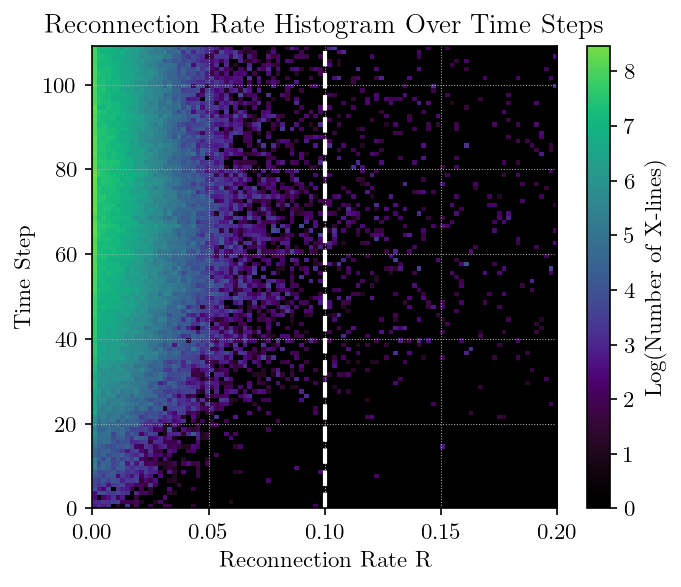

In [3]:

gradient = ["black", "orange", "green"]

filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_solar_wind"
#filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_quasiXlines"


all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))


def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    if len(data) == 0:
        print(f"Warning: No data found in {datapath}. Skipping.")
        return 0.0, np.array([])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    return x


bins=100
max_reconnection_rate = 0.2

plt.figure(figsize=(5,4), dpi=150)

all_histograms = []
for i, datapath in enumerate(all_files):
    #print(f"Processing {datapath}")
    data = plot_histogram(i, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
    all_histograms.append(data)

plt.imshow(np.log(np.array(all_histograms)+1), origin="lower", aspect='auto', cmap='cmr.lavender', interpolation='nearest', extent=[0, max_reconnection_rate, 0, number_of_files])
plt.colorbar(label='Log(Number of X-lines)')
plt.vlines(0.1, 0, number_of_files, color="white", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
plt.ylabel("Time Step")
plt.xlabel("Reconnection Rate R")
# plt.legend()
plt.title("Reconnection Rate Histogram Over Time Steps")

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_86430/699098139.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(bins[1:], expo(bins[1:], *popt), linewidth=1.5, color="black", label="Fit: $a e^{-b R^2} + \eta$")


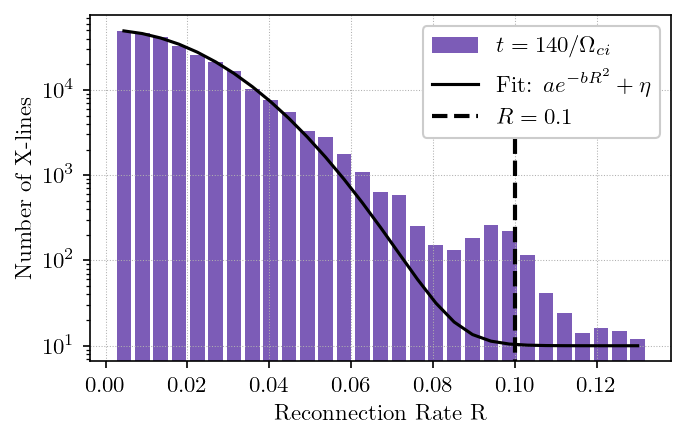

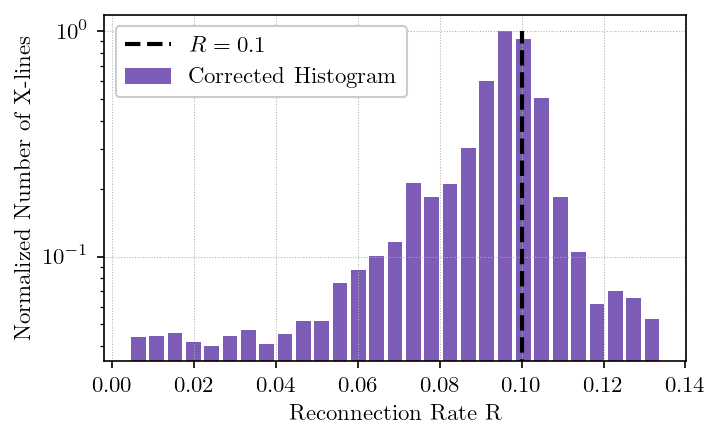

In [4]:
from scipy.optimize import curve_fit

def expo(x, a, b):
    return a * np.exp(-b * x**2 ) + 10

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, _ = np.histogram(data, bins=bins, density=False)
    
    xfit, yfit = bins[1:20], x[:19]
    popt, pcov = curve_fit(expo, xfit, yfit, p0=(1.0, 1.0), maxfev=10000)
    
    plt.figure(figsize=(5,3), dpi=150)
    plt.hist(data, bins=bins, density=False, color=gcolor("violet"), label=r"$t=140/\Omega_{ci}$", rwidth=0.8, align="right")
    plt.plot(bins[1:], expo(bins[1:], *popt), linewidth=1.5, color="black", label="Fit: $a e^{-b R^2} + \eta$")
    plt.vlines(0.1, 0.0, np.max(x), color="black", linestyle="--", linewidth=2.0, label="$R=0.1$")
    plt.yscale("log")
    plt.xlabel("Reconnection Rate R")
    plt.ylabel("Number of X-lines")
    plt.legend(framealpha=1.0)
    plt.show()
    
    # Correct the histogram and normalize
    x_norm = x / expo(bins[1:], *popt)
    x_norm = x_norm / np.max(x_norm)  
    
    plt.figure(figsize=(5,3), dpi=150)
    plt.bar(bins[1:], x_norm, width=np.diff(bins)*0.8, align='edge', color=gcolor("violet"), label="Corrected Histogram")
    plt.vlines(0.1, 0.0, np.max(x_norm), color="black", linestyle="--", linewidth=2.0, label="$R=0.1$")
    plt.yscale("log")
    plt.xlabel("Reconnection Rate R")
    plt.ylabel("Normalized Number of X-lines")
    plt.legend(framealpha=1.0)

datapath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_3.txt"
bins=30
max_reconnection_rate = 0.13


plot_histogram(1, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
# plt.savefig("reconnection_rate_histogram.png", bbox_inches="tight", dpi=300)

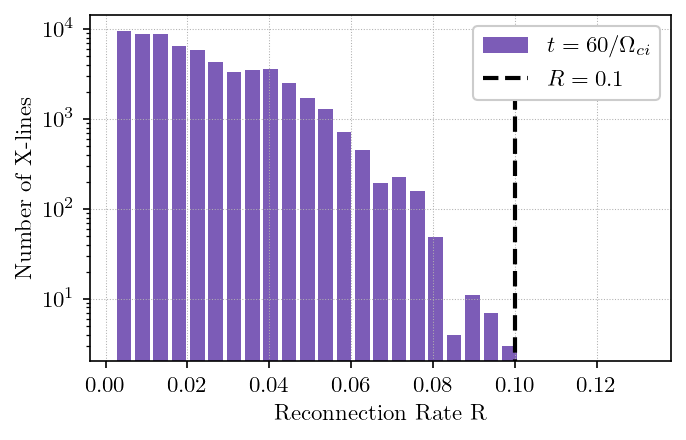

In [5]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    plt.hist(data, bins=bins, density=False, color=gcolor("violet"), label=r"$t=60/\Omega_{ci}$", rwidth=0.8, align="right")
    # plt.show()
    return np.max(x), data

datapath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_quasiXlines/reconnection_rates_step_0034.txt"
bins=30
max_reconnection_rate = 0.13

plt.figure(figsize=(5,3), dpi=150)

max_val_new, data = plot_histogram(1, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)

plt.vlines(0.1, 0.0, max_val_new, color="black", linestyle="--", linewidth=2.0, label="$R=0.1$")
plt.yscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend(framealpha=1.0)
plt.savefig("reconnection_rate_histogram_step_30.png", bbox_inches="tight", dpi=300)

<Figure size 600x450 with 0 Axes>

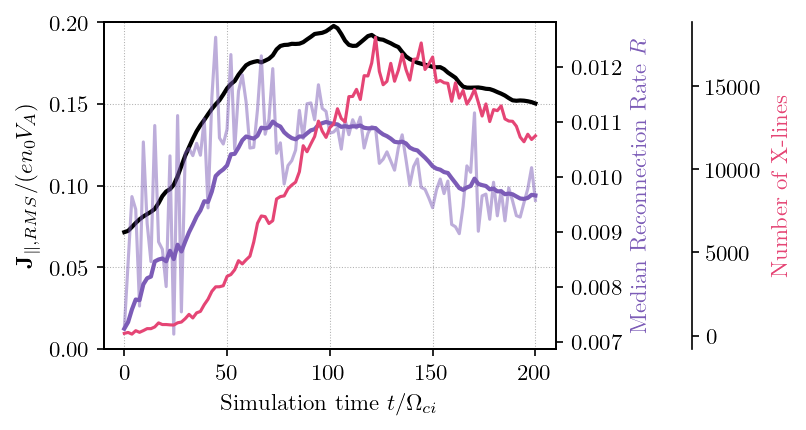

In [6]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")

def exponential_moving_average(x, alpha=0.1):
    ema = [x[0]]
    for i in range(1, len(x)):
        ema.append(alpha * x[i] + (1 - alpha) * ema[-1])
    return np.array(ema)

def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    n = len(data)
    if n == 0:
        return 0.0, 0
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 1.0)])
    max_r = np.median(data)
    
    return max_r, len(data)

plt.figure(figsize=(4,3), dpi=150)

max_reconnection_rates = []
number_of_lines = []
time_steps = []
for i, datapath in enumerate(all_files):
    max_r, n = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)
    number_of_lines.append(n)
    time_steps.append(i)

fig, ax1 = plt.subplots(figsize=(6,3), dpi=150)

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines.right.set_position(("axes", 1.3))

xlin = np.linspace(0, 200, len(max_reconnection_rates))

ax3.plot(xlin,number_of_lines, color="#e54575", linewidth=1.5)
ax3.set_ylabel("Number of X-lines", color="#e54575")
ax3.grid(False)

ax1.plot(xlin,current_density[:,1], color="black", linewidth=2)
ax1.set_ylim(0,0.2)
ax1.set_xlabel(r"Simulation time $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")

ax2.plot(xlin, max_reconnection_rates, color=gcolor("violet"), linewidth=1.5, alpha=0.5, label="Reconnection Rate $R$")
ax2.set_ylabel("Median Reconnection Rate $R$", color=gcolor("violet"))
ax2.grid(False)

ax2.plot(xlin, exponential_moving_average(max_reconnection_rates, alpha=0.1), color=gcolor("violet"), linestyle="-", linewidth=2, label="EMA Reconnection Rate $R$")


plt.tight_layout()
plt.savefig("num_points_lines.png", dpi=300)
plt.show()

In [9]:
print(np.corrcoef(current_density[:,1], exponential_moving_average(max_reconnection_rates, alpha=0.1))[0, 1])

0.977988795661522


In [10]:
print(np.corrcoef(current_density[:,1], number_of_lines)[0, 1])

0.747609637274827
